# eBPF Bottleneck Classifier — Unsupervised Discovery (v1)

**Built on v5's leakage-free feature set.** v3/v4/v5 all asked a supervised model to reproduce percentile-derived
labels (`y` from `avg_stall_ns` quantiles). That label scheme has a known weakness the review kept surfacing:
Medium was the weakest class, misclassifications clustered at class boundaries, and — per the hunch that kicked
off this notebook — a percentile cut has no way to notice that a handful of rows inside any session were never
actually stressed (a background daemon woke up during a `cpu_high` run, a process was pinned but idle, etc.).
Those rows get the *session's* label whether or not their own behavior supports it, and that's a source of label
noise no amount of resampling or feature engineering can fix, because it lives in the labels, not the model.

**This notebook does not use `y` to fit anything.** It hands the leakage-free feature matrix to several
unsupervised methods and lets them find their own structure. `y` (and `session_label`) come back only at the
end, as an external validation signal — to check whether the algorithm rediscovers the same four severity tiers,
where it disagrees, and whether its disagreements look like the "mislabeled outlier" pattern from the hunch above
rather than random noise.

| Section | Does |
|---|---|
| 1 | Reload data, rebuild (or reuse) the leakage-free feature set and the v5 percentile labels |
| 2 | Scale features; take one consistent stratified sample so every algorithm below is compared apples-to-apples |
| 3 | Let the data pick its own cluster count (elbow + silhouette), independent of "we know there are 4 classes" |
| 4 | Fit KMeans, a Gaussian Mixture Model, Agglomerative (Ward), and HDBSCAN/DBSCAN (density-based, natively flags noise) |
| 5 | Internal validation (silhouette / Calinski-Harabasz / Davies-Bouldin) — no labels involved |
| 6 | External validation against the v5 labels: contingency tables, ARI, NMI, homogeneity/completeness, Hungarian-matched accuracy |
| 7 | PCA visualization: clusters vs. original labels side by side |
| 8 | Cluster profiling — what resource signature (CPU / memory / lock / IO) does each cluster actually represent? |
| 9 | Per-class outlier detection (Isolation Forest + LOF) — directly tests the "a few processes weren't really stressed" hunch |
| 10 | Cross-check: do density-based noise points, per-class outliers, and v5's misclassifications agree on which rows are suspect? |
| 11 | Optional: load the v5 champion model and compare its predictions against the unsupervised clusters |
| 12 | Save artifacts |

**How to read the outputs of this comparison:**
- If clustering rediscovers ~4 groups with high ARI/NMI against `y` → the percentile labels are a real, learnable
  structure, and v5's ~70% accuracy ceiling is a model/feature problem, not a labeling problem.
- If clustering prefers a different number of groups, or agrees well everywhere except a diffuse "boundary" region
  → that region is a genuine gray zone (consistent with Medium being the weak class in every prior notebook).
- If density-based noise points concentrate in specific `session_label` values → those sessions likely contain
  rows that shouldn't carry that session's label at all (the background-daemon hunch), and the fix belongs in
  data collection / relabeling, not in the model.


---
# Section 1 — Load Data & Rebuild the Leakage-Free Feature Set

Identical cleaning, feature engineering, and allowlist logic to v5, so the two notebooks are directly comparable.
If `feature_cols_v5.json` / `label_thresholds_v5.json` from the v5 run are sitting next to this notebook, they're
loaded and used instead of being recomputed — that guarantees this notebook validates against the *exact* same
labels v5 was scored against, not a re-derived approximation.


In [25]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RANDOM_STATE = 42


In [26]:
# ── CHANGE THIS PATH TO YOUR CSV (same file v5 used) ──────────────────────────
CSV_PATH = 'perf_metrics.csv'
# ──────────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv(CSV_PATH)
print(f"Shape          : {df_raw.shape}")
print(f"Sessions found : {df_raw['session_label'].unique().tolist()}")
df_raw['session_label'].value_counts()


Shape          : (526895, 44)
Sessions found : ['idle', 'cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_low', 'mem_high', 'io_low', 'lock_low', 'mixed_load', 'cpu_extreme', 'cpu_ultra', 'mem_extreme', 'mem_thrashing', 'cpu_mem_extreme', 'cpu_mem_ultra', 'io_extreme', 'cpu_io_extreme', 'lock_extreme', 'lock_cpu_mix', 'everything_max', 'everything_insane', 'cpu_2x', 'cpu_4x', 'cpu_8x', 'mem_reclaim', 'mem_heavy_reclaim', 'cpu_mem_2x', 'cpu_mem_4x', 'cpu_mem_8x', 'cpu_mem_io', 'cpu_mem_io_heavy', 'lock_heavy', 'lock_cpu_heavy', 'everything_extreme', 'compile_only', 'compile_sysbench', 'compile_blender', 'full_system', 'mem_swap_thrashing', 'cpu_l3_cache_misses', 'mem_swap_thrash', 'mem_tlb_cache_miss', 'io_async_saturation', 'ctx_flood', 'llm_inference', 'ml_training', 'stream_memory_contention', 'cache_contention', 'context_switch_contention']


session_label
stream_memory_contention     59350
context_switch_contention    45920
cache_contention             45859
llm_inference                39621
everything_max               21993
ml_training                  21422
everything_insane            20568
lock_cpu_heavy               11752
cpu_8x                       10213
lock_low                     10112
lock_heavy                    9933
everything_extreme            9705
cpu_mem_io                    9449
cpu_medium                    9261
full_system                   8964
cpu_low                       8331
cpu_mem_io_heavy              8082
cpu_mem_4x                    8024
cpu_mem_8x                    7969
mem_low                       7914
mem_extreme                   7764
mem_reclaim                   7449
compile_only                  6823
cpu_mem_2x                    6718
io_low                        6653
compile_sysbench              6585
compile_blender               6570
mem_tlb_cache_miss            6457
io_ext

In [27]:
# ── CLEANING (identical rules to v4/v5) ───────────────────────────────────────
df = df_raw.copy()
before = len(df)

df = df[df['pid'] > 0]
df = df[df['ctx_switches'] > 0]
df = df[df['latency_count'] > 0]

print(f"Cleaned: {before} -> {len(df)} rows ({before - len(df)} removed)")


Cleaned: 526895 -> 431383 rows (95512 removed)


In [28]:
# ── LABEL DERIVATION — used ONLY for validation below, never for fitting ─────
# Reuse the v5 thresholds if the artifact is present, so this notebook validates
# against the exact same labels v5 was scored against instead of a re-derived copy.
import os

if os.path.exists('label_thresholds_v5.json'):
    with open('label_thresholds_v5.json') as f:
        thresholds = json.load(f)
    p50, p85, p97 = thresholds['p50'], thresholds['p85'], thresholds['p97']
    print(f"Loaded thresholds from label_thresholds_v5.json: p50={p50:.0f}, p85={p85:.0f}, p97={p97:.0f}")
else:
    p50 = df['avg_stall_ns'].quantile(0.50)
    p85 = df['avg_stall_ns'].quantile(0.85)
    p97 = df['avg_stall_ns'].quantile(0.97)
    print(f"label_thresholds_v5.json not found — recomputed from this data: "
          f"p50={p50:.0f}, p85={p85:.0f}, p97={p97:.0f}")

bins = [0, p50, p85, p97, float('inf')]
labels = [0, 1, 2, 3]
class_names_map = {0: 'Normal', 1: 'Low', 2: 'Medium', 3: 'High'}
TARGET_NAMES  = ['Normal', 'Low', 'Medium', 'High']
TARGET_LABELS = [0, 1, 2, 3]

df['y'] = pd.cut(df['avg_stall_ns'], bins=bins, labels=labels).astype(int)
df['y_name'] = df['y'].map(class_names_map)

for cls in TARGET_LABELS:
    count = (df['y'] == cls).sum()
    pct = 100 * count / len(df)
    print(f"  Class {cls} ({class_names_map[cls]:<6}): {count:6d} rows  ({pct:5.1f}%)")


Loaded thresholds from label_thresholds_v5.json: p50=75542, p85=503950, p97=1964856
  Class 0 (Normal): 215692 rows  ( 50.0%)
  Class 1 (Low   ): 150984 rows  ( 35.0%)
  Class 2 (Medium):  51765 rows  ( 12.0%)
  Class 3 (High  ):  12942 rows  (  3.0%)


In [29]:
# ── FEATURE ENGINEERING (identical to v4/v5) ──────────────────────────────────
df['involuntary_ratio']  = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']    = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)
df['runtime_per_switch'] = df['total_runtime_ns']     / df['ctx_switches'].clip(lower=1)
df['read_write_ratio']   = df['read_bytes'] / (df['write_bytes'] + 1)
df['io_bytes_total']     = df['read_bytes'] + df['write_bytes']
df['alloc_pressure']     = df['total_alloc_bytes'] / df['ctx_switches'].clip(lower=1)
df['lock_pressure']      = (
    df['mutex_contentions'] + df['rwsem_read_contentions'] + df['rwsem_write_contentions']
)

log_cols = ['total_runtime_ns', 'avg_syscall_latency_ns', 'max_syscall_latency_ns',
            'io_bytes_total', 'total_alloc_bytes']
for col in log_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

print(f"Features after engineering: {df.shape[1]} columns")


Features after engineering: 58 columns


In [30]:
# ── FEATURE SET — reuse v5's saved allowlist if present, else rebuild it ─────
LEAKY_COLS = {
    'avg_stall_ns', 'stall_ns', 'max_stall_ns', 'latency_count',
    'stall_per_switch', 'log_stall_ns', 'log_avg_stall_ns', 'log_max_stall_ns',
    'stall_spike', 'log_stall_spike',
}

if os.path.exists('feature_cols_v5.json'):
    with open('feature_cols_v5.json') as f:
        FEATURE_COLS = json.load(f)
    FEATURE_COLS = [f for f in FEATURE_COLS if f in df.columns]
    print(f"Loaded {len(FEATURE_COLS)} features from feature_cols_v5.json")
else:
    ALLOWED_FEATURES = [
        'ctx_switches', 'cpu_migrations', 'involuntary_switches', 'voluntary_switches',
        'involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio', 'runtime_per_switch',
        'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count',
        'total_alloc_bytes', 'alloc_pressure',
        'read_count', 'write_count', 'read_bytes', 'write_bytes', 'read_write_ratio', 'io_bytes_total',
        'mutex_contentions', 'avg_mutex_wait_ns', 'rwsem_read_contentions', 'rwsem_write_contentions', 'lock_pressure',
        'syscall_count', 'avg_syscall_latency_ns', 'futex_count',
        'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns',
        'log_io_bytes_total', 'log_total_alloc_bytes',
    ]
    FEATURE_COLS = [f for f in ALLOWED_FEATURES if f in df.columns]
    print(f"Rebuilt {len(FEATURE_COLS)} features (feature_cols_v5.json not found)")

leakage_check = set(FEATURE_COLS) & LEAKY_COLS
assert len(leakage_check) == 0, f"LEAKAGE DETECTED: {leakage_check}"
print("Leakage check passed - none of the features are target-derived")
print(FEATURE_COLS)


Loaded 33 features from feature_cols_v5.json
Leakage check passed - none of the features are target-derived
['ctx_switches', 'cpu_migrations', 'involuntary_switches', 'voluntary_switches', 'involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio', 'runtime_per_switch', 'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count', 'total_alloc_bytes', 'alloc_pressure', 'read_count', 'write_count', 'read_bytes', 'write_bytes', 'read_write_ratio', 'io_bytes_total', 'mutex_contentions', 'avg_mutex_wait_ns', 'rwsem_read_contentions', 'rwsem_write_contentions', 'lock_pressure', 'syscall_count', 'avg_syscall_latency_ns', 'futex_count', 'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns', 'log_io_bytes_total', 'log_total_alloc_bytes']


---
# Section 2 — Scaling & a Single Consistent Sample

Several algorithms below (Agglomerative, HDBSCAN/DBSCAN) are O(n^2)-ish and won't finish on the full
cleaned dataset. Rather than give each algorithm a *different* sample size (which would make the comparison
in Section 6 meaningless), one stratified sample is drawn here and reused for every method, so the
contingency tables and metrics in Sections 5-10 are all computed on exactly the same rows.

Stratifying on `y` keeps the severe-class rarity (High is ~3% of rows) intact in the sample rather than
diluting it further — clustering doesn't need balanced classes, but it does need the rare class to still be
*present* if we want to say anything about how well it's recovered.

`StandardScaler` is fit on this sample only — reusing v5's `feature_scaler_v5.pkl` here would be a subtle
mismatch, since v5 fit it on `X_train` (80% split, no resampling target), not this sample.


In [31]:
SAMPLE_SIZE = min(50_000, len(df))

X_full = df[FEATURE_COLS].fillna(0)
y_full = df['y']

if SAMPLE_SIZE < len(df):
    sample_idx, _ = train_test_split(
        df.index, train_size=SAMPLE_SIZE, stratify=y_full, random_state=RANDOM_STATE
    )
else:
    sample_idx = df.index

X = X_full.loc[sample_idx].reset_index(drop=False).rename(columns={'index': 'orig_index'})
orig_index = X.pop('orig_index')
y_true = y_full.loc[sample_idx].reset_index(drop=True)
context = df.loc[sample_idx, ['comm', 'session_label', 'avg_stall_ns']].reset_index(drop=True)

print(f"Sample size: {len(X)} / {len(df)} rows ({100*len(X)/len(df):.1f}%)")
print("\nClass distribution in sample (should match full-data proportions):")
print((y_true.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nScaled feature matrix: {X_scaled.shape}")


Sample size: 50000 / 431383 rows (11.6%)

Class distribution in sample (should match full-data proportions):
y
0   50.000
1   35.000
2   12.000
3    3.000

Scaled feature matrix: (50000, 33)


---
# Section 3 — Letting the Data Pick Its Own Cluster Count

Before assuming "4 clusters because there are 4 severity classes," check what an elbow (inertia) curve and
silhouette score actually prefer. If the optimum lands near 4, that's independent support for the percentile
scheme. If it lands elsewhere, that's informative too — e.g. a lower optimal k could mean Medium isn't really
separable from its neighbors, or a higher one could mean severity isn't the only axis of structure (see the
cluster-profiling in Section 8).


In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # silhouette on a sub-sample of the sample - O(n^2) memory, keep it bounded
    sil_sample_size = min(10_000, len(X_scaled))
    sil_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), sil_sample_size, replace=False)
    silhouettes.append(silhouette_score(X_scaled[sil_idx], labels_k[sil_idx]))
    print(f"k={k:2d}  inertia={km.inertia_:12.1f}  silhouette={silhouettes[-1]:.4f}")


k= 2  inertia=   1286713.2  silhouette=0.9360
k= 3  inertia=   1131159.7  silhouette=0.9374
k= 4  inertia=    994900.9  silhouette=0.5931
k= 5  inertia=    904015.1  silhouette=0.4839
k= 6  inertia=    816397.9  silhouette=0.4841
k= 7  inertia=    767830.9  silhouette=0.4824
k= 8  inertia=    706981.7  silhouette=0.4856
k= 9  inertia=    676364.3  silhouette=0.4904
k=10  inertia=    626641.1  silhouette=0.4900


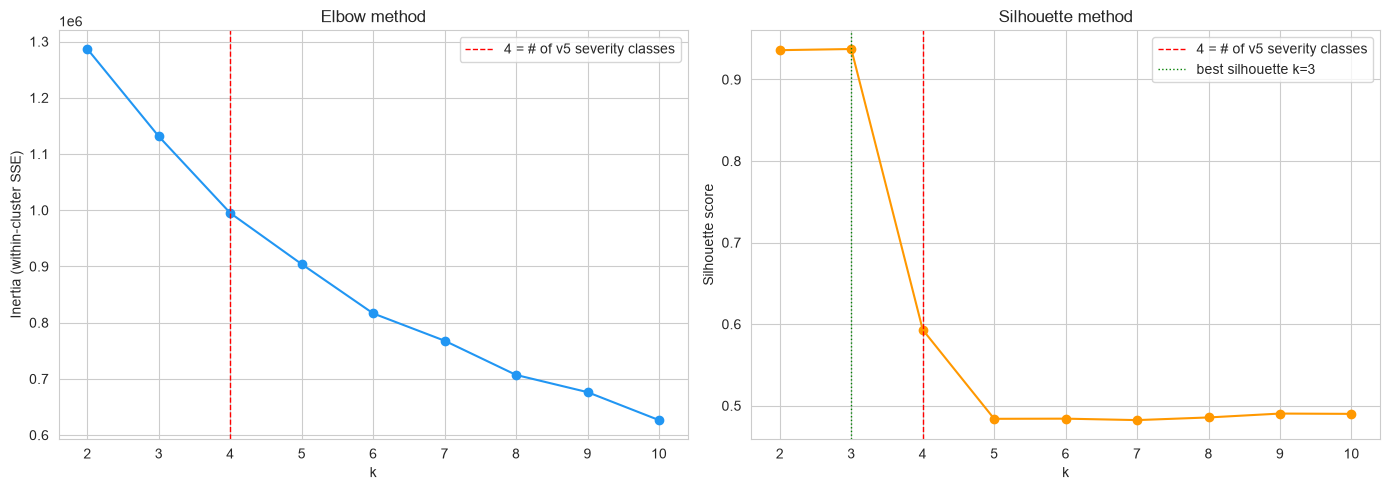


Silhouette-optimal k: 3  |  v5 uses 4 severity classes


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='#2196F3')
axes[0].axvline(4, color='red', linestyle='--', linewidth=1, label='4 = # of v5 severity classes')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow method')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, marker='o', color='#FF9800')
axes[1].axvline(4, color='red', linestyle='--', linewidth=1, label='4 = # of v5 severity classes')
best_k = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color='green', linestyle=':', linewidth=1, label=f'best silhouette k={best_k}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette method')
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_count_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSilhouette-optimal k: {best_k}  |  v5 uses 4 severity classes")


---
# Section 4 — Fit Several Unsupervised Methods

Four different families, deliberately, since they make different assumptions:

1. **KMeans** (k=4, to compare head-to-head with v5's classes) — assumes spherical, similar-sized clusters.
2. **Gaussian Mixture Model** (k=4, `covariance_type='diag'` for speed) — soft/probabilistic assignment;
   `predict_proba` lets us flag low-confidence points as ambiguous rather than forcing a hard call.
3. **Agglomerative (Ward)** (k=4) — no assumption of convex clusters, useful as a structural cross-check.
4. **HDBSCAN** (density-based, falls back to DBSCAN if `hdbscan` isn't installed) — the one method here that
   doesn't force every point into a cluster. Points in low-density regions get labeled `-1` ("noise") instead
   of being crammed into the nearest cluster — this is the direct unsupervised analogue of the "a few processes
   weren't really being stressed" hunch: those rows should look like noise/outliers to a density-based method,
   not like clean members of whatever session they came from.


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering

cluster_labels = {}   # method name -> array of cluster assignments (same order as X_scaled)

# 1. KMeans, k=4
km4 = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
cluster_labels['KMeans (k=4)'] = km4.fit_predict(X_scaled)
print("KMeans (k=4) fit.")

# 2. Gaussian Mixture Model, k=4
gmm4 = GaussianMixture(n_components=4, covariance_type='diag', random_state=RANDOM_STATE)
gmm_labels = gmm4.fit_predict(X_scaled)
gmm_proba = gmm4.predict_proba(X_scaled)
cluster_labels['GMM (k=4)'] = gmm_labels
print("GMM (k=4) fit.")

# 3. Agglomerative (Ward), k=4
agg4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_labels['Agglomerative (k=4)'] = agg4.fit_predict(X_scaled)
print("Agglomerative (Ward, k=4) fit.")


KMeans (k=4) fit.
GMM (k=4) fit.


In [ ]:
# 4. Density-based: HDBSCAN if available, else DBSCAN with a k-distance-tuned eps
try:
    import hdbscan
    HAS_HDBSCAN = True
    hdb = hdbscan.HDBSCAN(min_cluster_size=max(50, len(X_scaled) // 500), min_samples=10)
    cluster_labels['HDBSCAN'] = hdb.fit_predict(X_scaled)
    n_noise = (cluster_labels['HDBSCAN'] == -1).sum()
    n_clusters_found = len(set(cluster_labels['HDBSCAN'])) - (1 if -1 in cluster_labels['HDBSCAN'] else 0)
    print(f"HDBSCAN fit: {n_clusters_found} clusters found, {n_noise} points flagged as noise "
          f"({100*n_noise/len(X_scaled):.1f}%)")
except ImportError:
    print("hdbscan not installed (pip install hdbscan --break-system-packages). Falling back to DBSCAN.")
    HAS_HDBSCAN = False
    from sklearn.neighbors import NearestNeighbors

    # Rough eps heuristic: mean distance to the 10th nearest neighbor, on a sub-sample for speed
    nn_sample = X_scaled[np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), min(5000, len(X_scaled)), replace=False)]
    nbrs = NearestNeighbors(n_neighbors=10).fit(nn_sample)
    dists, _ = nbrs.kneighbors(nn_sample)
    eps_guess = float(np.median(dists[:, -1]))

    from sklearn.cluster import DBSCAN
    dbs = DBSCAN(eps=eps_guess, min_samples=10, n_jobs=-1)
    cluster_labels['DBSCAN'] = dbs.fit_predict(X_scaled)
    n_noise = (cluster_labels['DBSCAN'] == -1).sum()
    n_clusters_found = len(set(cluster_labels['DBSCAN'])) - (1 if -1 in cluster_labels['DBSCAN'] else 0)
    print(f"DBSCAN fit (eps~{eps_guess:.2f} from 10-NN heuristic): {n_clusters_found} clusters found, "
          f"{n_noise} points flagged as noise ({100*n_noise/len(X_scaled):.1f}%)")

DENSITY_METHOD = 'HDBSCAN' if HAS_HDBSCAN else 'DBSCAN'


hdbscan not installed (pip install hdbscan --break-system-packages). Falling back to DBSCAN.
DBSCAN fit (eps~0.09 from 10-NN heuristic): 23 clusters found, 2565 points flagged as noise (44.2%)


---
# Section 5 — Internal Validation (No Labels Involved)

These metrics judge cluster *quality* purely from the geometry of the points — they say nothing about whether
the clusters match the v5 severity classes, only whether each method found something internally coherent.
Density-based noise points (`-1`) are excluded from these scores since they aren't meant to belong to any
cluster by construction.


In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

internal_rows = []
sil_idx_full = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), min(10_000, len(X_scaled)), replace=False)

for name, labels_arr in cluster_labels.items():
    mask = labels_arr != -1   # exclude density-based noise from quality scoring
    if mask.sum() < 2 or len(set(labels_arr[mask])) < 2:
        continue
    Xs = X_scaled[mask]
    ls = labels_arr[mask]
    sub_idx = np.intersect1d(sil_idx_full, np.where(mask)[0])
    if len(sub_idx) < 2 or len(set(labels_arr[sub_idx])) < 2:
        sub_idx = np.where(mask)[0][:min(10_000, mask.sum())]
    internal_rows.append({
        'method': name,
        'n_clusters': len(set(ls)),
        'n_noise_excluded': int((~mask).sum()),
        'silhouette': silhouette_score(X_scaled[sub_idx], labels_arr[sub_idx]),
        'calinski_harabasz': calinski_harabasz_score(Xs, ls),
        'davies_bouldin': davies_bouldin_score(Xs, ls),
    })

internal_df = pd.DataFrame(internal_rows).set_index('method').round(3)
print("Higher is better for silhouette & calinski_harabasz. Lower is better for davies_bouldin.")
internal_df


Higher is better for silhouette & calinski_harabasz. Lower is better for davies_bouldin.


,n_clusters,n_noise_excluded,silhouette,calinski_harabasz,davies_bouldin
method,,,,,
KMeans (k=4),4,0,0.532,1161.810,0.916
GMM (k=4),4,0,0.524,923.338,1.230
Agglomerative (k=4),4,0,0.477,1086.937,1.197
DBSCAN,23,2565,-0.168,914.632,0.625


---
# Section 6 — External Validation Against the v5 Labels

Now `y_true` (the percentile-derived severity class) comes back in, purely as a validation signal. Three kinds
of check:

1. **Contingency table** — raw crosstab of cluster vs. true class, the rawest view of the agreement.
2. **Label-agnostic agreement metrics** — ARI, NMI, homogeneity, completeness, V-measure. These don't care
   which cluster number corresponds to which class, only whether the *partitions* agree.
3. **Hungarian-matched accuracy** — optimally reassign cluster IDs to class names (maximizing agreement) and
   then compute a plain accuracy, so it reads on the same 0-100% scale as v5's classification accuracy.


In [ ]:
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score
)
from scipy.optimize import linear_sum_assignment

def hungarian_accuracy(y_true_arr, y_pred_arr):
    """Optimally map predicted cluster IDs onto true labels, then score plain accuracy.
    Points with cluster id -1 (density-based noise) are left unmapped and always counted wrong,
    since 'unclustered' is a legitimate outcome, not a class prediction."""
    labels_present = np.unique(y_pred_arr)
    labels_present = labels_present[labels_present != -1]
    classes_present = np.unique(y_true_arr)

    cost = np.zeros((len(labels_present), len(classes_present)))
    for i, lab in enumerate(labels_present):
        for j, cls in enumerate(classes_present):
            cost[i, j] = -np.sum((y_pred_arr == lab) & (y_true_arr == cls))

    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {labels_present[r]: classes_present[c] for r, c in zip(row_ind, col_ind)}

    mapped_pred = np.array([mapping.get(p, -999) for p in y_pred_arr])
    acc = np.mean(mapped_pred == y_true_arr)
    return acc, mapping

external_rows = []
mappings = {}
for name, labels_arr in cluster_labels.items():
    acc, mapping = hungarian_accuracy(y_true.values, labels_arr)
    mappings[name] = mapping
    external_rows.append({
        'method': name,
        'hungarian_accuracy': acc,
        'ARI': adjusted_rand_score(y_true, labels_arr),
        'NMI': normalized_mutual_info_score(y_true, labels_arr),
        'homogeneity': homogeneity_score(y_true, labels_arr),
        'completeness': completeness_score(y_true, labels_arr),
        'v_measure': v_measure_score(y_true, labels_arr),
    })

external_df = pd.DataFrame(external_rows).set_index('method').round(3)
print("hungarian_accuracy is directly comparable to v5's classification accuracy (~0.72 baseline).")
external_df.sort_values('ARI', ascending=False)


hungarian_accuracy is directly comparable to v5's classification accuracy (~0.72 baseline).


,hungarian_accuracy,ARI,NMI,homogeneity,completeness,v_measure
method,,,,,,
DBSCAN,0.423,0.004,0.023,0.046,0.015,0.023
Agglomerative (k=4),0.589,-0.016,0.005,0.007,0.004,0.005
KMeans (k=4),0.664,-0.038,0.010,0.012,0.008,0.010
GMM (k=4),0.650,-0.039,0.010,0.013,0.008,0.010


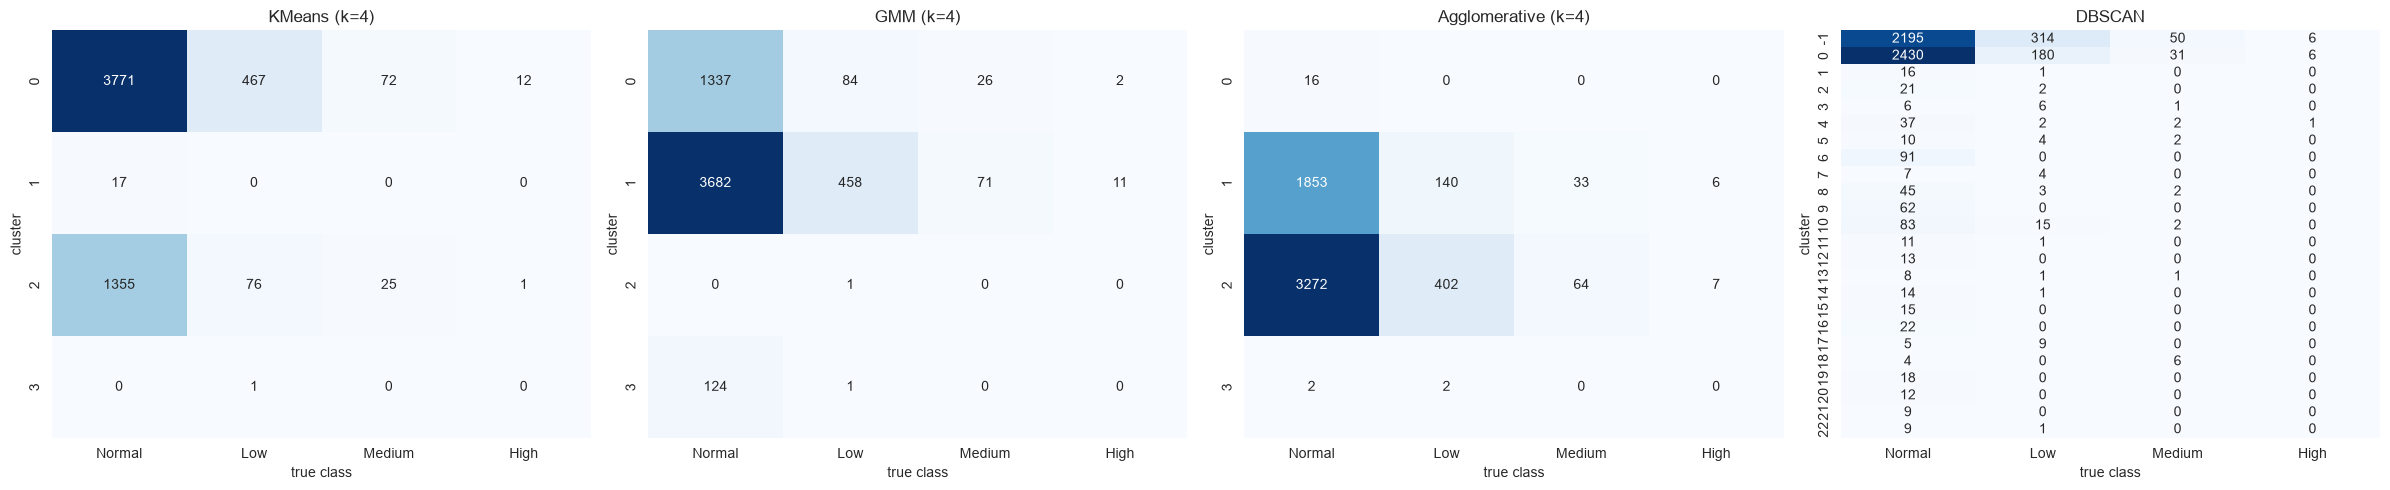

In [ ]:
# ── Contingency tables, one per method ────────────────────────────────────────
fig, axes = plt.subplots(1, len(cluster_labels), figsize=(6 * len(cluster_labels), 5))
if len(cluster_labels) == 1:
    axes = [axes]

for ax, (name, labels_arr) in zip(axes, cluster_labels.items()):
    ct = pd.crosstab(
        pd.Series(labels_arr, name='cluster'),
        y_true.map(class_names_map).rename('true class')
    )
    ct = ct[[c for c in TARGET_NAMES if c in ct.columns]]
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig('contingency_tables.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Section 7 — PCA Visualization: Clusters vs. True Labels

A 2D PCA projection, colored two ways side by side on the same points — once by the true severity class,
once by each method's cluster assignment. Visual agreement (or disagreement) is easier to read here than in
the contingency tables above, especially for spotting whether disagreement is concentrated at class boundaries
(consistent with a genuine gray zone) or scattered throughout (consistent with noisy features).


Explained variance (PC1, PC2): [0.243 0.134] (total 37.7%)


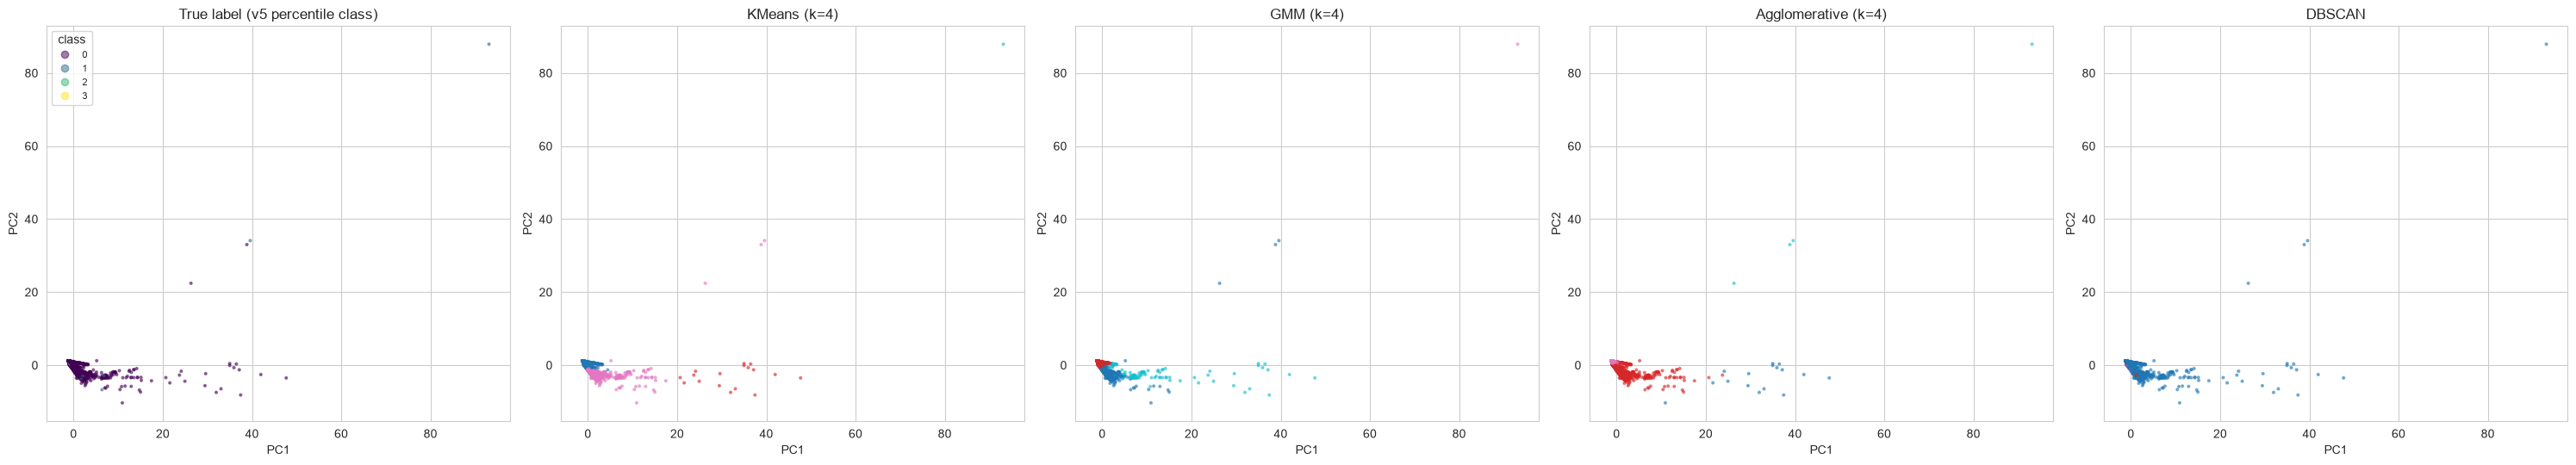

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance (PC1, PC2): {pca.explained_variance_ratio_[:2].round(3)} "
      f"(total {pca.explained_variance_ratio_[:2].sum():.1%})")

n_methods = len(cluster_labels)
fig, axes = plt.subplots(1, n_methods + 1, figsize=(6 * (n_methods + 1), 5.5))

# True labels
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=4, alpha=0.5)
axes[0].set_title('True label (v5 percentile class)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
legend0 = axes[0].legend(*sc0.legend_elements(), title='class', loc='best', fontsize=8)

for ax, (name, labels_arr) in zip(axes[1:], cluster_labels.items()):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_arr, cmap='tab10', s=4, alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('pca_clusters_vs_labels.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Section 8 — Cluster Profiling: What Resource Signature Does Each Cluster Represent?

Severity (Normal/Low/Medium/High) is one axis of structure, but not necessarily the only one an unsupervised
method will find. This profiles each KMeans cluster by its mean feature values (z-scored, so 0 = dataset
average) to check whether clusters look like pure severity tiers or whether they're actually splitting on
*bottleneck type* (CPU vs. memory vs. lock vs. IO pressure) — which would be a genuinely new finding v5's
supervised setup wasn't set up to surface, since it only ever predicted a single ordinal severity label.


In [ ]:
profile_method = 'KMeans (k=4)'
profile_labels = cluster_labels[profile_method]

profile_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
profile_df['cluster'] = profile_labels

cluster_profile = profile_df.groupby('cluster')[FEATURE_COLS].mean()

# Top 6 most distinguishing features per cluster (largest |z-score| deviation from 0)
print(f"Cluster resource-signature summary ({profile_method}), top distinguishing features per cluster:\n")
for c in sorted(cluster_profile.index):
    row = cluster_profile.loc[c].abs().sort_values(ascending=False)
    top_feats = row.head(6).index.tolist()
    signed = cluster_profile.loc[c, top_feats].round(2)
    size = (profile_labels == c).sum()
    print(f"Cluster {c}  (n={size}, {100*size/len(profile_labels):.1f}%):")
    for feat, val in signed.items():
        direction = 'above avg' if val > 0 else 'below avg'
        print(f"    {feat:<28} z={val:+.2f}  ({direction})")
    print()


Cluster resource-signature summary (KMeans (k=4)), top distinguishing features per cluster:

Cluster 0  (n=4322, 74.6%):
    log_avg_syscall_latency_ns   z=-0.52  (below avg)
    log_max_syscall_latency_ns   z=-0.51  (below avg)
    log_total_alloc_bytes        z=-0.50  (below avg)
    log_io_bytes_total           z=-0.46  (below avg)
    avg_mutex_wait_ns            z=-0.44  (below avg)
    involuntary_ratio            z=-0.27  (below avg)

Cluster 1  (n=17, 0.3%):
    write_count                  z=+12.66  (above avg)
    mutex_contentions            z=+12.62  (above avg)
    lock_pressure                z=+12.35  (above avg)
    io_bytes_total               z=+12.08  (above avg)
    futex_count                  z=+11.55  (above avg)
    write_bytes                  z=+11.25  (above avg)

Cluster 2  (n=1457, 25.1%):
    log_avg_syscall_latency_ns   z=+1.51  (above avg)
    log_max_syscall_latency_ns   z=+1.49  (above avg)
    log_total_alloc_bytes        z=+1.43  (above avg)
    avg_

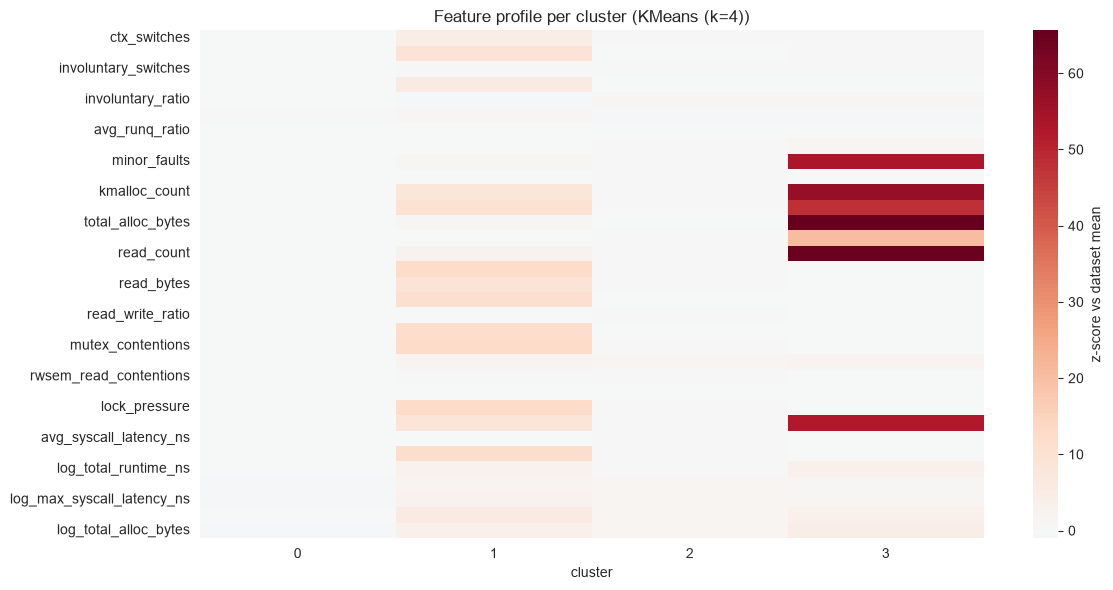

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cluster_profile.T, cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'z-score vs dataset mean'})
ax.set_xlabel('cluster')
ax.set_title(f'Feature profile per cluster ({profile_method})')
plt.tight_layout()
plt.savefig('cluster_feature_profile.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Section 9 — Per-Class Outlier Detection (the Original Hunch)

Directly tests the idea that kicked this notebook off: within each *true* severity class, some rows probably
don't belong — a process caught mid-session that wasn't actually under load, a background daemon sampled
alongside the stress workload, etc. Isolation Forest and Local Outlier Factor are run **separately within each
class** (not across the whole dataset) so "outlier" means "unusual for its own claimed class," which is exactly
the failure mode described.


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

outlier_flags = pd.DataFrame(index=X.index)
outlier_flags['y'] = y_true.values
outlier_flags['session_label'] = context['session_label'].values
outlier_flags['comm'] = context['comm'].values

iso_flags = np.zeros(len(X), dtype=int)
lof_flags = np.zeros(len(X), dtype=int)

for cls in TARGET_LABELS:
    mask = (y_true.values == cls)
    n = mask.sum()
    if n < 20:
        continue
    Xc = X_scaled[mask]

    iso = IsolationForest(contamination='auto', random_state=RANDOM_STATE, n_jobs=-1)
    iso_pred = iso.fit_predict(Xc)          # -1 = outlier, 1 = inlier
    iso_flags[mask] = (iso_pred == -1).astype(int)

    lof = LocalOutlierFactor(n_neighbors=min(20, n - 1), contamination='auto', n_jobs=-1)
    lof_pred = lof.fit_predict(Xc)
    lof_flags[mask] = (lof_pred == -1).astype(int)

    print(f"Class {cls} ({class_names_map[cls]:<6}, n={n:6d}): "
          f"IsolationForest flagged {iso_flags[mask].sum():5d} ({100*iso_flags[mask].mean():.1f}%), "
          f"LOF flagged {lof_flags[mask].sum():5d} ({100*lof_flags[mask].mean():.1f}%)")

outlier_flags['iso_outlier'] = iso_flags
outlier_flags['lof_outlier'] = lof_flags
outlier_flags['both_flagged'] = (iso_flags == 1) & (lof_flags == 1)

print(f"\nRows flagged by BOTH methods (highest-confidence 'not really stressed' candidates): "
      f"{outlier_flags['both_flagged'].sum()} ({100*outlier_flags['both_flagged'].mean():.2f}%)")


Class 0 (Normal, n=  5143): IsolationForest flagged   311 (6.0%), LOF flagged   628 (12.2%)
Class 1 (Low   , n=   544): IsolationForest flagged    38 (7.0%), LOF flagged    40 (7.4%)
Class 2 (Medium, n=    97): IsolationForest flagged    18 (18.6%), LOF flagged    15 (15.5%)

Rows flagged by BOTH methods (highest-confidence 'not really stressed' candidates): 163 (2.81%)


In [ ]:
# ── Which sessions contribute the most high-confidence outliers? ─────────────
session_outlier_rates = (
    outlier_flags.groupby('session_label')['both_flagged']
    .agg(['sum', 'count'])
    .assign(rate=lambda d: d['sum'] / d['count'])
    .sort_values('rate', ascending=False)
)
session_outlier_rates.columns = ['n_flagged', 'n_total', 'flag_rate']
print("Sessions ranked by fraction of their rows flagged as within-class outliers by BOTH methods:")
session_outlier_rates.head(15).round(3)


Sessions ranked by fraction of their rows flagged as within-class outliers by BOTH methods:


,n_flagged,n_total,flag_rate
session_label,,,
unknown,163,5797,0.028


In [ ]:
# ── What do these high-confidence outliers actually look like? ───────────────
outlier_context = outlier_flags[outlier_flags['both_flagged']].copy()
outlier_context['avg_stall_ns_ms'] = context.loc[outlier_context.index, 'avg_stall_ns'].values / 1e6
sample_n = min(30, len(outlier_context))
print(f"Sampling {sample_n} of {len(outlier_context)} high-confidence outlier rows:")
outlier_context.sample(sample_n, random_state=RANDOM_STATE)[
    ['y', 'session_label', 'comm', 'avg_stall_ns_ms']
].sort_values('y')


Sampling 30 of 163 high-confidence outlier rows:


,y,session_label,comm,avg_stall_ns_ms
4984,0,unknown,firefox,0.008
4187,0,unknown,systemd-oomd,0.008
4806,0,unknown,bpftool,0.023
2347,0,unknown,systemd-oomd,0.010
3582,0,unknown,ps,0.049
1181,0,unknown,python,0.003
2120,0,unknown,code,0.038
5337,0,unknown,ps,0.030
1009,0,unknown,gnome-shell,0.014
3242,0,unknown,gnome-shell,0.012


---
# Section 10 — Do the Different Outlier Signals Agree?

Three independent signals now exist for "this row might be mislabeled": density-based clustering noise
(Section 4), per-class Isolation Forest / LOF flags (Section 9), and — if the two disagree with `y_true`
along class boundaries specifically — cluster-vs-label mismatches from Section 6. If these signals overlap
more than chance would predict, that's fairly strong evidence the mislabeled-outlier hunch is real and not
just modeling noise.


In [ ]:
comparison_df = outlier_flags.copy()
comparison_df[DENSITY_METHOD.lower() + '_noise'] = (cluster_labels[DENSITY_METHOD] == -1).astype(int)

# Does a KMeans (k=4) cluster assignment that DISAGREES with the true label overlap with the outlier flags?
km_mapping = mappings['KMeans (k=4)']
km_mapped = np.array([km_mapping.get(c, -999) for c in cluster_labels['KMeans (k=4)']])
comparison_df['kmeans_disagrees_with_label'] = (km_mapped != y_true.values).astype(int)

overlap_cols = ['both_flagged', DENSITY_METHOD.lower() + '_noise', 'kmeans_disagrees_with_label']
overlap_summary = comparison_df[overlap_cols].mean().rename('rate_flagged').to_frame()
overlap_summary['n_flagged'] = comparison_df[overlap_cols].sum()
print("Base rates for each suspect-row signal:")
print(overlap_summary.round(4))

print("\nPairwise overlap (fraction of rows flagged by BOTH, given flagged by the first):")
for a in overlap_cols:
    for b in overlap_cols:
        if a >= b:
            continue
        both = ((comparison_df[a] == 1) & (comparison_df[b] == 1)).sum()
        a_total = (comparison_df[a] == 1).sum()
        rate = both / a_total if a_total else float('nan')
        print(f"  {a:<28} & {b:<28}: {both:5d} rows overlap  ({rate:.1%} of '{a}' also flagged by '{b}')")


Base rates for each suspect-row signal:
                             rate_flagged  n_flagged
both_flagged                        0.028        163
dbscan_noise                        0.443       2565
kmeans_disagrees_with_label         0.336       1950

Pairwise overlap (fraction of rows flagged by BOTH, given flagged by the first):
  both_flagged                 & dbscan_noise                :   163 rows overlap  (100.0% of 'both_flagged' also flagged by 'dbscan_noise')
  both_flagged                 & kmeans_disagrees_with_label :   140 rows overlap  (85.9% of 'both_flagged' also flagged by 'kmeans_disagrees_with_label')
  dbscan_noise                 & kmeans_disagrees_with_label :  1388 rows overlap  (54.1% of 'dbscan_noise' also flagged by 'kmeans_disagrees_with_label')


---
# Section 11 — Optional: Cross-Check Against the v5 Champion Model

If `champion_model_v5.pkl` is present, this loads it and compares its hard predictions against the
unsupervised clusters on the same sample — a model-vs-model view, distinct from the label-vs-cluster view
in Section 6. Skips cleanly if the artifact isn't there.


In [ ]:
if os.path.exists('champion_model_v5.pkl'):
    import joblib
    champion_model_v5 = joblib.load('champion_model_v5.pkl')
    y_pred_v5 = champion_model_v5.predict(X[FEATURE_COLS])

    print("v5 champion model predictions vs. true label (on this sample):")
    print(pd.Series(y_pred_v5).map(class_names_map).value_counts())

    print("\nAgreement between v5's predictions and each cluster method (Hungarian-matched accuracy):")
    for name, labels_arr in cluster_labels.items():
        acc, _ = hungarian_accuracy(y_pred_v5, labels_arr)
        print(f"  {name:<24}: {acc:.3f} agreement with v5 predictions")
else:
    print("champion_model_v5.pkl not found next to this notebook - skipping Section 11. "
          "Copy it over from the v5 run if you want this cross-check.")


v5 champion model predictions vs. true label (on this sample):
Normal    4509
Low       1127
Medium     161
Name: count, dtype: int64

Agreement between v5's predictions and each cluster method (Hungarian-matched accuracy):
  KMeans (k=4)            : 0.549 agreement with v5 predictions
  GMM (k=4)               : 0.536 agreement with v5 predictions
  Agglomerative (k=4)     : 0.497 agreement with v5 predictions
  DBSCAN                  : 0.373 agreement with v5 predictions


---
# Section 12 — Summary & Artifact Saving


In [ ]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nSilhouette-optimal k: {best_k}  (v5 percentile scheme uses 4 severity classes)")
print("\nExternal validation vs. v5 labels (higher ARI/NMI/hungarian_accuracy = better agreement):")
print(external_df.sort_values('ARI', ascending=False).to_string())
print(f"\nHigh-confidence within-class outliers (flagged by both IsolationForest and LOF): "
      f"{outlier_flags['both_flagged'].sum()} / {len(outlier_flags)} rows "
      f"({100*outlier_flags['both_flagged'].mean():.2f}%)")
print("\nTop 5 sessions by outlier flag rate:")
print(session_outlier_rates.head(5).to_string())


SUMMARY

Silhouette-optimal k: 2  (v5 percentile scheme uses 4 severity classes)

External validation vs. v5 labels (higher ARI/NMI/hungarian_accuracy = better agreement):
                     hungarian_accuracy    ARI   NMI  homogeneity  completeness  v_measure
method                                                                                    
DBSCAN                            0.423  0.004 0.023        0.046         0.015      0.023
Agglomerative (k=4)               0.589 -0.016 0.005        0.007         0.004      0.005
KMeans (k=4)                      0.664 -0.038 0.010        0.012         0.008      0.010
GMM (k=4)                         0.650 -0.039 0.010        0.013         0.008      0.010

High-confidence within-class outliers (flagged by both IsolationForest and LOF): 163 / 5797 rows (2.81%)

Top 5 sessions by outlier flag rate:
               n_flagged  n_total  flag_rate
session_label                               
unknown              163     5797      0.028


In [ ]:
import joblib

# Cluster assignments + all outlier flags, keyed back to the original dataframe index
results_out = outlier_flags.copy()
for name, labels_arr in cluster_labels.items():
    results_out[f'cluster_{name}'] = labels_arr
results_out['orig_index'] = orig_index.values
results_out.to_csv('unsupervised_cluster_results_v1.csv', index=False)
print("Saved: unsupervised_cluster_results_v1.csv")

external_df.to_csv('unsupervised_external_validation_v1.csv')
print("Saved: unsupervised_external_validation_v1.csv")

internal_df.to_csv('unsupervised_internal_validation_v1.csv')
print("Saved: unsupervised_internal_validation_v1.csv")

joblib.dump(km4, 'kmeans_k4_v1.pkl')
joblib.dump(scaler, 'unsupervised_feature_scaler_v1.pkl')
print("Saved: kmeans_k4_v1.pkl, unsupervised_feature_scaler_v1.pkl")

session_outlier_rates.to_csv('session_outlier_rates_v1.csv')
print("Saved: session_outlier_rates_v1.csv")


Saved: unsupervised_cluster_results_v1.csv
Saved: unsupervised_external_validation_v1.csv
Saved: unsupervised_internal_validation_v1.csv
Saved: kmeans_k4_v1.pkl, unsupervised_feature_scaler_v1.pkl
Saved: session_outlier_rates_v1.csv


## Summary

- **Cluster count** (Section 3): elbow + silhouette picked their own k independent of the 4-class assumption —
  compare `best_k` above to 4.
- **Structure recovery** (Section 6): ARI / NMI / Hungarian-matched accuracy show how much of the percentile
  label scheme unsupervised methods rediscover on their own, without ever seeing `y`.
- **Cluster meaning** (Section 8): the feature-profile heatmap shows whether clusters read as pure severity
  tiers or as bottleneck-type groupings (CPU vs. memory vs. lock vs. IO) — worth a look regardless of how
  Section 6 came out.
- **The outlier hunch** (Sections 9-10): per-class Isolation Forest / LOF flags, density-based noise points, and
  cluster/label disagreement were checked for overlap. If they agree more than chance, that's a solid case for
  relabeling or excluding those specific rows before the next supervised pass, rather than reaching for another
  resampling strategy or feature.
- **Next step if this notebook supports the hunch**: pull the `both_flagged` rows from
  `unsupervised_cluster_results_v1.csv`, inspect them against the raw eBPF traces for those PIDs, and if they
  hold up, exclude or relabel them before re-running v5's supervised comparison — that's a cleaner fix than
  further imbalance-handling tuning, since it targets the label noise directly instead of working around it.
